# Ising Model

Using the pseudocode from Schroeder, Introduction to Thermal Physics, chapter 8.2

Model a 2D magnet at temperature $T$. Each grid point contains a magnetic dipole that can be spin-up or spin-down.

The critical temperature of the Ising model is $T_c=2.27\ \mathrm{K}$ which is where the phase transition occurs. At temperatures below the critical temperature, the model is highly ordered and magnetic domains are created which is where spins tend to point in the same direction as their neighbors. Above $T_c$ the spins are in random directions.

In [1]:
import numpy as np
import imageio.v3 as iio
import os
import matplotlib.pyplot as plt
import time
from IPython.display import Image, display

In [2]:
def deltaU(s, i, j, size):
    """
    Find the difference in energy if the site (i,j) was flipped

    Difference in energy is twice the energy of the site times the energy of its neighbor,
    and sum over all 4 neighbors (not including diagonal neighbors)

    Enforce periodic boundary conditions. Left side goes to right side, down side goes to up side
    Really means the shape of spins are on the surface of a torus

    Args:
    `s`: the spin 2d matrix
    `i`: x index
    `j`: y index
    """
    if i == 0:
        top = s[size - 1, j]
    else:
        top = s[i - 1, j]
    if i == size - 1:
        bottom = s[0, j]
    else:
        bottom = s[i + 1, j]
    if j == 0:
        left = s[i, size - 1]
    else:
        left = s[i, j - 1]
    if j == size - 1:
        right = s[i, 0]
    else:
        right = s[i, j + 1]

    return 2 * s[i, j] * (top + bottom + left + right)

def initRandom(s, size):
    """
    Initialize the grid to a random collection of spin up and spin down
    """
    for i in range(size):
        for j in range(size):
            if np.random.random() < 0.5:
                s[i, j] = 1
            else:
                s[i, j] = -1
    return s

def initMagnetized(s, state: int, size):
    """
    Initialize the grid to a magnetized state, works better for lower temperature simulations

    Args:
    `state`: 1 or -1
    """
    for i in range(size):
        for j in range(size):
            s[i, j] = state
    return s

def calcMagnetization(s: np.ndarray, size):
    """
    Calculate the magnetization, which is defined as the sum of all spins in the grid
    """
    sum = 0
    for i in range(size):
        for j in range(size):
            sum += s[i, j]
    return sum

def calcCorrelation(s: np.ndarray):
    """ 
    Caculate the spatial correlation along the x and y dimensions.
    """
    dim_x = s.shape[0]
    dim_y = s.shape[1]

    correlation_x_per_r = np.zeros((dim_x // 2, dim_x * dim_y))
    correlation_y_per_r = np.zeros((dim_y // 2, dim_x * dim_y))

    # calculate x correlation
    for r in range(dim_x // 2):
        for j in range(dim_y):
            for i in range(dim_x):
                this_site = i
                other_site = (i + r) % dim_x
                product = s[this_site, j] * s[other_site, j]
                offset = s[this_site, j] ** 2

                correlation_x_per_r[r, dim_y * j + i] = product - offset

    avg_corr_x = correlation_x_per_r.mean(axis=1)

    # calculate y correlation
    for r in range(dim_y // 2):
        for i in range(dim_x):
            for j in range(dim_y):
                this_site = j
                other_site = (j + r) % dim_y
                product = s[i, this_site] * s[i, other_site]
                offset = s[i, this_site] ** 2

                correlation_y_per_r[r, dim_x * i + j] = product - offset

    avg_corr_y = correlation_y_per_r.mean(axis=1)

    return avg_corr_x, avg_corr_y

Run a simulation showing the state of the magnet after the algorithm has completed

The color of the grid represents the spin.
- Dark = spin up
- Light = spin down

In [3]:
def normal_sim(
    size,
    temp,
    iterations=400,
    create_gif=False,
    show_correlation=False,
    correlation_step=50):
    
    s = np.empty((size, size))
    # s = initializeMagnetized(s, state=1)
    s = initRandom(s, size)
    cwd = os.getcwd()
    folder_name = f"{cwd}/ising_model_states"
    os.makedirs(folder_name, exist_ok=True)

    fig, ax = plt.subplots()

    startTime = time.time()

    magnetization_over_time = []
    magnetization_bins = []

    print("Starting...")
    for state_iter in range(iterations):
        print(f"Calculating state {state_iter}")
        for site_iter in range(size**2):
            # choose a random site
            i = int(np.random.random() * size)
            j = int(np.random.random() * size)
            # calculate energy difference
            Ediff = deltaU(s, i, j, size)
            # if flipping reduces the energy, flip it
            if Ediff <= 0:
                s[i, j] = -s[i, j]
            # if not, then flip it randomly, where the cutoff is that the number needs to be less than the Boltzman factor
            elif np.random.random() < np.exp(-Ediff / temp):
                s[i, j] = -s[i, j]

        if show_correlation:
            if state_iter % correlation_step == 0:
                corr_x, corr_y = calcCorrelation(s)
                r = [i + 1 for i in range(size // 2)]
                plt.plot(r, corr_x, marker=".", color="orange", label="X")
                plt.xlabel("r")
                plt.ylabel("Correlation")
                plt.plot(r, corr_y, marker=".", color="royalblue", label="Y")
                plt.legend()
                plt.show()

        if create_gif:
            plt.imsave(f"{folder_name}/state_{state_iter}.png", s, cmap="Blues")

        m = calcMagnetization(s, size)
        magnetization_over_time.append(m)

        magnetization_bins.append(m)

    print(f"Total time: {time.time() - startTime:.2f} s")

    if create_gif:
        images = []
        for state_iter in range(iterations):
            images.append(iio.imread(f"{folder_name}/state_{state_iter}.png"))

        iio.imwrite(f"{cwd}/ising_model_T_{temp}.gif", images, format="gif", fps=30)
    
    plt.imshow(s, cmap='Blues')
    plt.title("Final state")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.show()

    plt.plot(magnetization_over_time, color="#1C78CD")
    plt.xlabel("Iteration")
    plt.ylabel("Magnetization")
    plt.show()

    plt.hist(magnetization_bins, bins=int(iterations / 10), color="#16974A")
    plt.xlabel("Magnetization")
    plt.ylabel("Count")
    plt.show()

Modeling the system at $T=0.4K$ shows it reaching a steady state with a net magnetization.

Starting...
Calculating state 0
Calculating state 1
Calculating state 2
Calculating state 3
Calculating state 4
Calculating state 5
Calculating state 6
Calculating state 7
Calculating state 8
Calculating state 9
Calculating state 10
Calculating state 11
Calculating state 12
Calculating state 13
Calculating state 14
Calculating state 15
Calculating state 16
Calculating state 17
Calculating state 18
Calculating state 19
Calculating state 20
Calculating state 21
Calculating state 22
Calculating state 23
Calculating state 24
Calculating state 25
Calculating state 26
Calculating state 27
Calculating state 28
Calculating state 29
Calculating state 30
Calculating state 31
Calculating state 32
Calculating state 33
Calculating state 34
Calculating state 35
Calculating state 36
Calculating state 37
Calculating state 38
Calculating state 39
Calculating state 40
Calculating state 41
Calculating state 42
Calculating state 43
Calculating state 44
Calculating state 45
Calculating state 46
Calculating

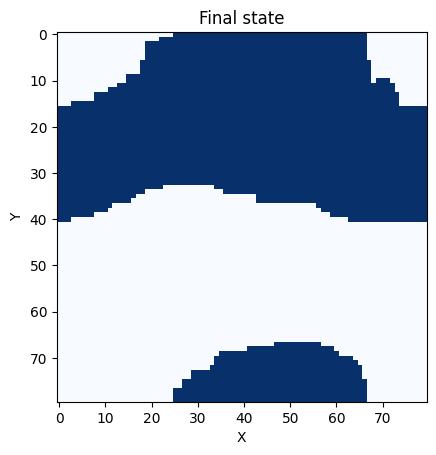

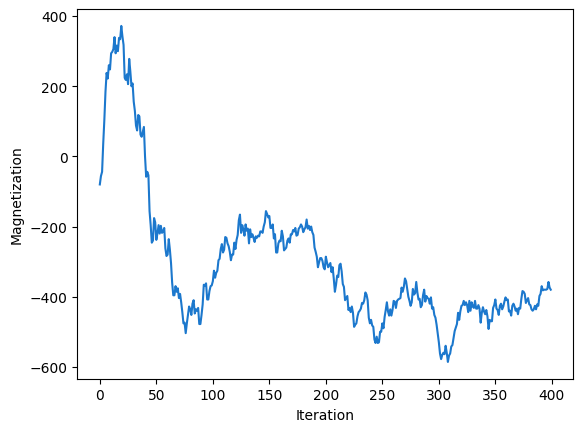

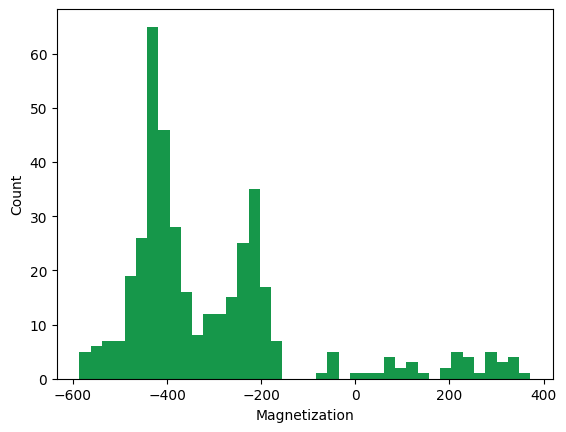

In [4]:
normal_sim(
    size=80,
    temp=0.4,
    create_gif=True
)

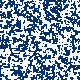

In [5]:
with open('ising_model_T_0.4.gif', 'rb') as f:
    display(Image(data=f.read(), format='gif'))

Modeling the system at $T=4K$ shows no net magnetization, i.e. it averages out to zero across the magnet.

Starting...
Calculating state 0
Calculating state 1
Calculating state 2
Calculating state 3
Calculating state 4
Calculating state 5
Calculating state 6
Calculating state 7
Calculating state 8
Calculating state 9
Calculating state 10
Calculating state 11
Calculating state 12
Calculating state 13
Calculating state 14
Calculating state 15
Calculating state 16
Calculating state 17
Calculating state 18
Calculating state 19
Calculating state 20
Calculating state 21
Calculating state 22
Calculating state 23
Calculating state 24
Calculating state 25
Calculating state 26
Calculating state 27
Calculating state 28
Calculating state 29
Calculating state 30
Calculating state 31
Calculating state 32
Calculating state 33
Calculating state 34
Calculating state 35
Calculating state 36
Calculating state 37
Calculating state 38
Calculating state 39
Calculating state 40
Calculating state 41
Calculating state 42
Calculating state 43
Calculating state 44
Calculating state 45
Calculating state 46
Calculating

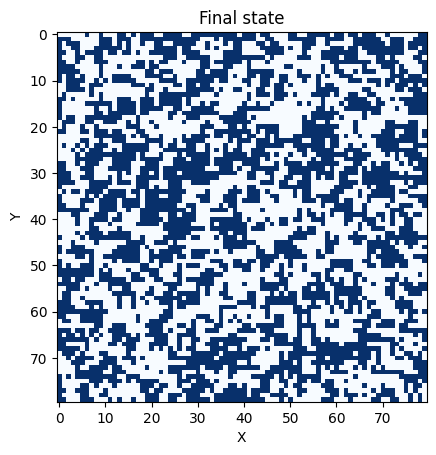

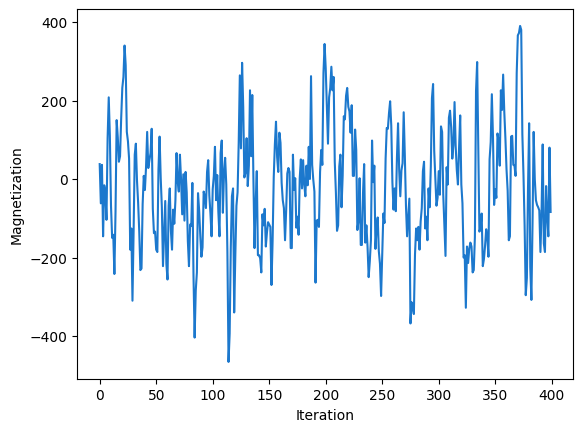

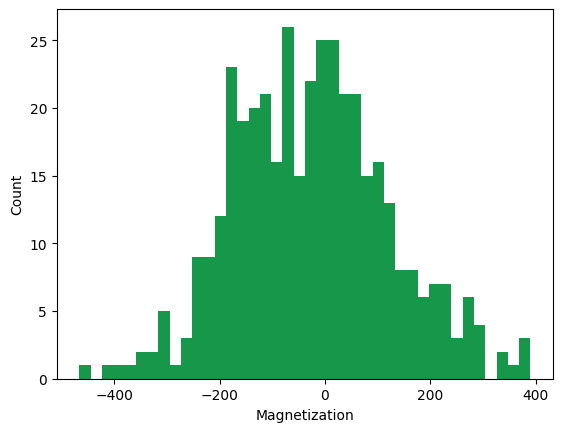

In [6]:
normal_sim(
    size=80,
    temp=4,
    create_gif=True
)

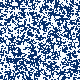

In [7]:
with open('ising_model_T_4.gif', 'rb') as f:
    display(Image(data=f.read(), format='gif'))

In [8]:
def correlation_vs_temp_sim(size, temp_list):
    """
    Plot the correlation function at several temperatures
    Waits for the system to equilibriate before calculating the correlation function

    """
    s = np.empty((size, size))
    # s = initializeMagnetized(s, state=1)
    s = initRandom(s, size)
    cwd = os.getcwd()
    folder_name = f"{cwd}\\ising_model_states"
    os.makedirs(folder_name, exist_ok=True)

    fig, ax = plt.subplots()

    startTime = time.time()

    corr_x_vs_T = []
    corr_y_vs_T = []

    print("Starting...")
    for T in temp_list:
        print(f"Calculating T={T}K")
        for state_iter in range(500):
            for site_iter in range(size**2):
                # choose a random site
                i = int(np.random.random() * size)
                j = int(np.random.random() * size)
                # calculate energy difference
                Ediff = deltaU(s, i, j, size=size)
                # if flipping reduces the energy, flip it
                if Ediff <= 0:
                    s[i, j] = -s[i, j]
                # if not, then flip it randomly, where the cutoff is that the number needs to be less than the Boltzman factor
                elif np.random.random() < np.exp(-Ediff / T):
                    s[i, j] = -s[i, j]

        corr_x, corr_y = calcCorrelation(s)
        avg_corr_x = corr_x.mean()
        avg_corr_y = corr_y.mean()

        corr_x_vs_T.append(avg_corr_x)
        corr_y_vs_T.append(avg_corr_y)

    print(f"Total time: {time.time() - startTime:.2f} s")

    plt.plot(temp_list, corr_x_vs_T, marker=".", color="magenta", label="X")
    plt.plot(temp_list, corr_y_vs_T, marker=".", color="royalblue", label="Y")
    plt.xlabel("Temperature [K]")
    plt.ylabel("Correlation")
    plt.legend()
    plt.show()

Perform the simulation over several temperature ranges from 1K -> 10K to estimate where the critical temperature occurs.

Starting...
Calculating T=1.0K
Calculating T=1.128837891684689K
Calculating T=1.2742749857031337K
Calculating T=1.4384498882876628K
Calculating T=1.6237767391887217K
Calculating T=1.8329807108324359K
Calculating T=2.0691380811147897K
Calculating T=2.3357214690901222K
Calculating T=2.636650898730358K
Calculating T=2.976351441631318K
Calculating T=3.3598182862837818K
Calculating T=3.79269019073225K
Calculating T=4.281332398719393K
Calculating T=4.832930238571752K
Calculating T=5.455594781168519K
Calculating T=6.158482110660264K
Calculating T=6.951927961775605K
Calculating T=7.847599703514611K
Calculating T=8.858667904100825K
Calculating T=10.0K
Total time: 21.38 s


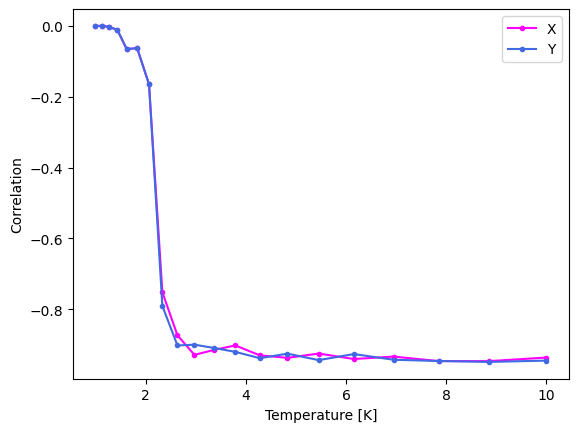

In [9]:
temps = np.logspace(0, 1, 20)
correlation_vs_temp_sim(size=40, temp_list=temps)

And we can see that X and Y correlation approaches -1 (which means most pairs of dipoles are antiparallel, i.e. not aligned) right after $T=2K$ which agrees with the theoretical value $T_c\approx 2.27K$. 